## Learning Linearvariate Regression on House Pricing Data

In [46]:
#Importing required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
df= pd.read_csv('housing_price_dataset.csv');
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [32]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB
None

Missing values:
 SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

Statistical Summary:
          SquareFeet      Bedrooms     Bathrooms     YearBuilt          Price
count  50000.000000  50000.000000  50000.000000  50000.000000   50000.000000
mean    2006.374680      3.498700      1.995420   1985.404420  224827.325151
std      575.513241      1.116326      0.815851     20.719377   76141.842966
min     100

In [33]:
# Remove negative price
df = df[df["Price"] > 0]

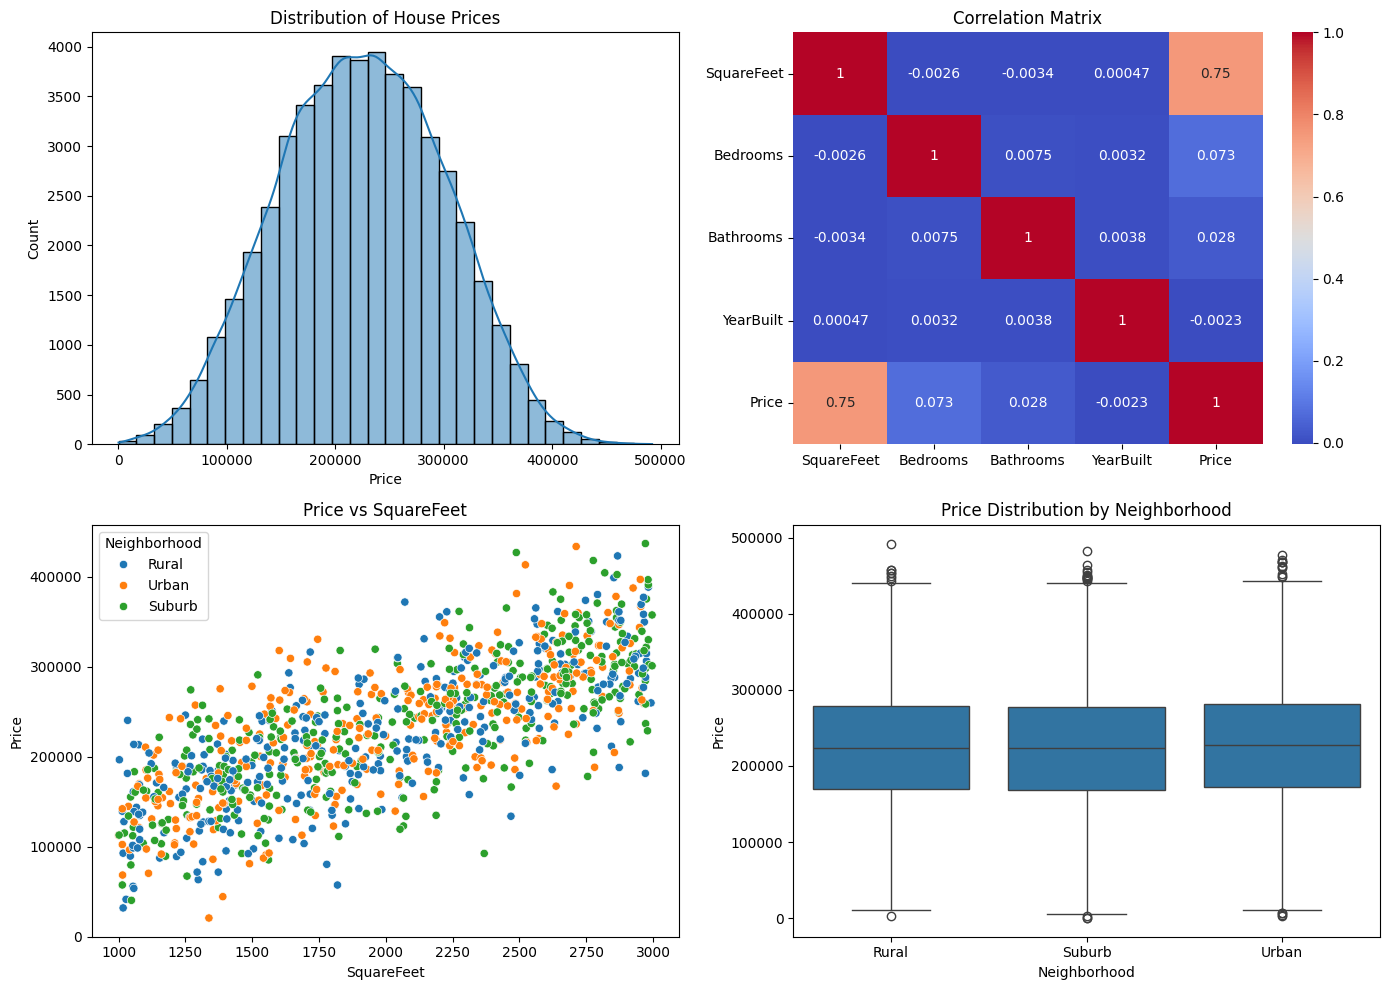

In [34]:
plt.figure(figsize=(14, 10))

# Distribution of Price
plt.subplot(2, 2, 1)
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Distribution of House Prices")

# Correlation heatmap
plt.subplot(2, 2, 2)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

# Sample for scatterplot
sample_df = df.sample(1000, random_state=42)

# Price vs SquareFeet
plt.subplot(2, 2, 3)
sns.scatterplot(data=sample_df, x="SquareFeet", y="Price", hue="Neighborhood")
plt.title("Price vs SquareFeet")

# Price by Neighborhood
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="Neighborhood", y="Price")
plt.title("Price Distribution by Neighborhood")

plt.tight_layout()
plt.show()

In [41]:
# Creating a LabelEncoder instance
le = LabelEncoder()
# Applying label encoding to the 'Neighborhood' column
df['Neighborhood'] = le.fit_transform(df['Neighborhood'])
X= df.drop("Price", axis=1)
y = df["Price"]


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [44]:
y_pred = model.predict(X_test)

In [48]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Root Mean Squared Error: 49448.45
R² Score: 0.58


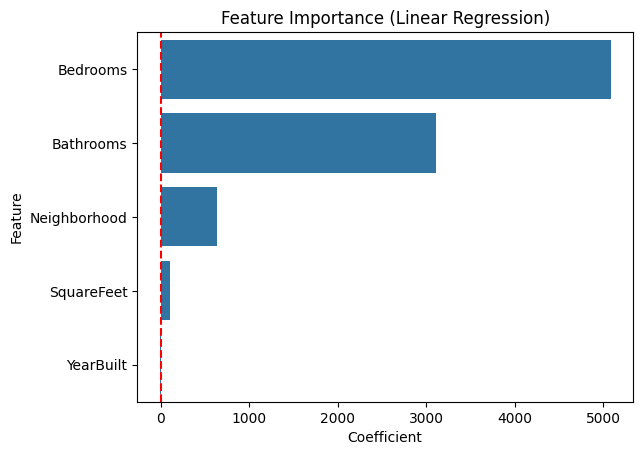

,Feature,Coefficient
1,Bedrooms,5081.039581
2,Bathrooms,3103.852888
3,Neighborhood,639.032495
0,SquareFeet,99.075517
4,YearBuilt,-13.294105


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_ #Coefficients learned by the linear regression model.
}).sort_values(by="Coefficient", key=abs, ascending=False)

# Plot the coefficients
sns.barplot(data=coefficients, x="Coefficient", y="Feature")
plt.title("Feature Importance (Linear Regression)")
plt.axvline(0, color="red", linestyle="--")
plt.show()

coefficients

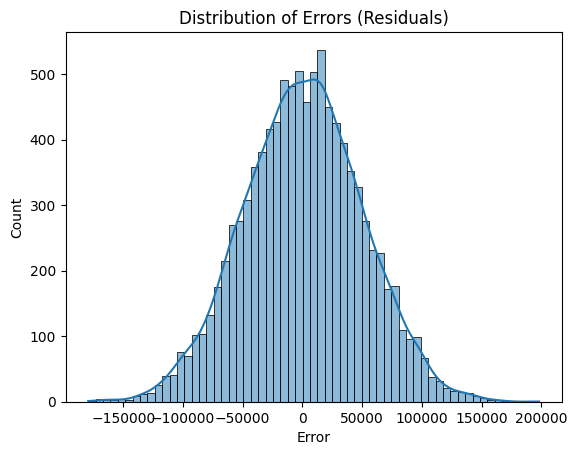

In [50]:
residuals = y_test - y_pred

# Histogram of errors
sns.histplot(residuals, kde=True)
plt.title("Distribution of Errors (Residuals)")
plt.xlabel("Error")
plt.show()